# Patrón 11: CUA — Computer Use Agent

### ¿Qué es?
Un **Computer Use Agent (CUA)** es un sistema donde el LLM/VLM puede interactuar con una computadora real o virtual — usando el cursor, teclado y navegador — para completar tareas en nombre del usuario. Los CUAs usan la capacidad de visión de modelos multimodales para interpretar el estado de la pantalla (screenshot) y ejecutan acciones de bajo nivel sobre el entorno. El agente opera en un loop de **observación → planificación → acción** hasta completar la tarea.

Es la arquitectura detrás de **Claude Operator** (Anthropic), **OpenAI CUA** y **browser-use**. Claude alcanza resultados state-of-the-art en WebArena, el benchmark de navegación web autónoma.

Caso de uso: Agente de Monitoreo de Precios con Playwright + LangGraph

Dataset / Fuente: books.toscrape.com — sitio de práctica de scraping 100% libre y legal, sin autenticación, diseñado para ser scrapeado. Simula un catálogo de productos con precios y ratings.

Dependencias:

```bash
# Instalar dependencias principales
!pip install -q langchain-anthropic langgraph langchain-core

# Playwright para browser automation (CUA sin VM externa)
!pip install -q playwright
!playwright install chromium --with-deps

# Utilidades
!pip install -q nest-asyncio pandas tabulate
```

### Action Space del CUA

| Categoría    | Acciones disponibles                                                           |
| ------------ | ------------------------------------------------------------------------------ |
| **Mouse**    | `click(x,y)` · `right_click(x,y)` · `drag(x1,y1,x2,y2)` · `scroll(x,y,dir)`    |
| **Keyboard** | `type(text)` · `key(Enter)` · `hotkey(Ctrl+C)` · `key_down/up(key)`            |
| **Screen**   | `screenshot()` · `get_accessibility_tree()` · `ocr(region)` · `find_element()` |
| **Browser**  | `navigate(url)` · `get_dom()` · `wait_for(selector)` · `evaluate(js)`          |
| **File**     | `read_file(path)` · `write_file(path, content)` · `bash(cmd)`                  |

Diagrama:
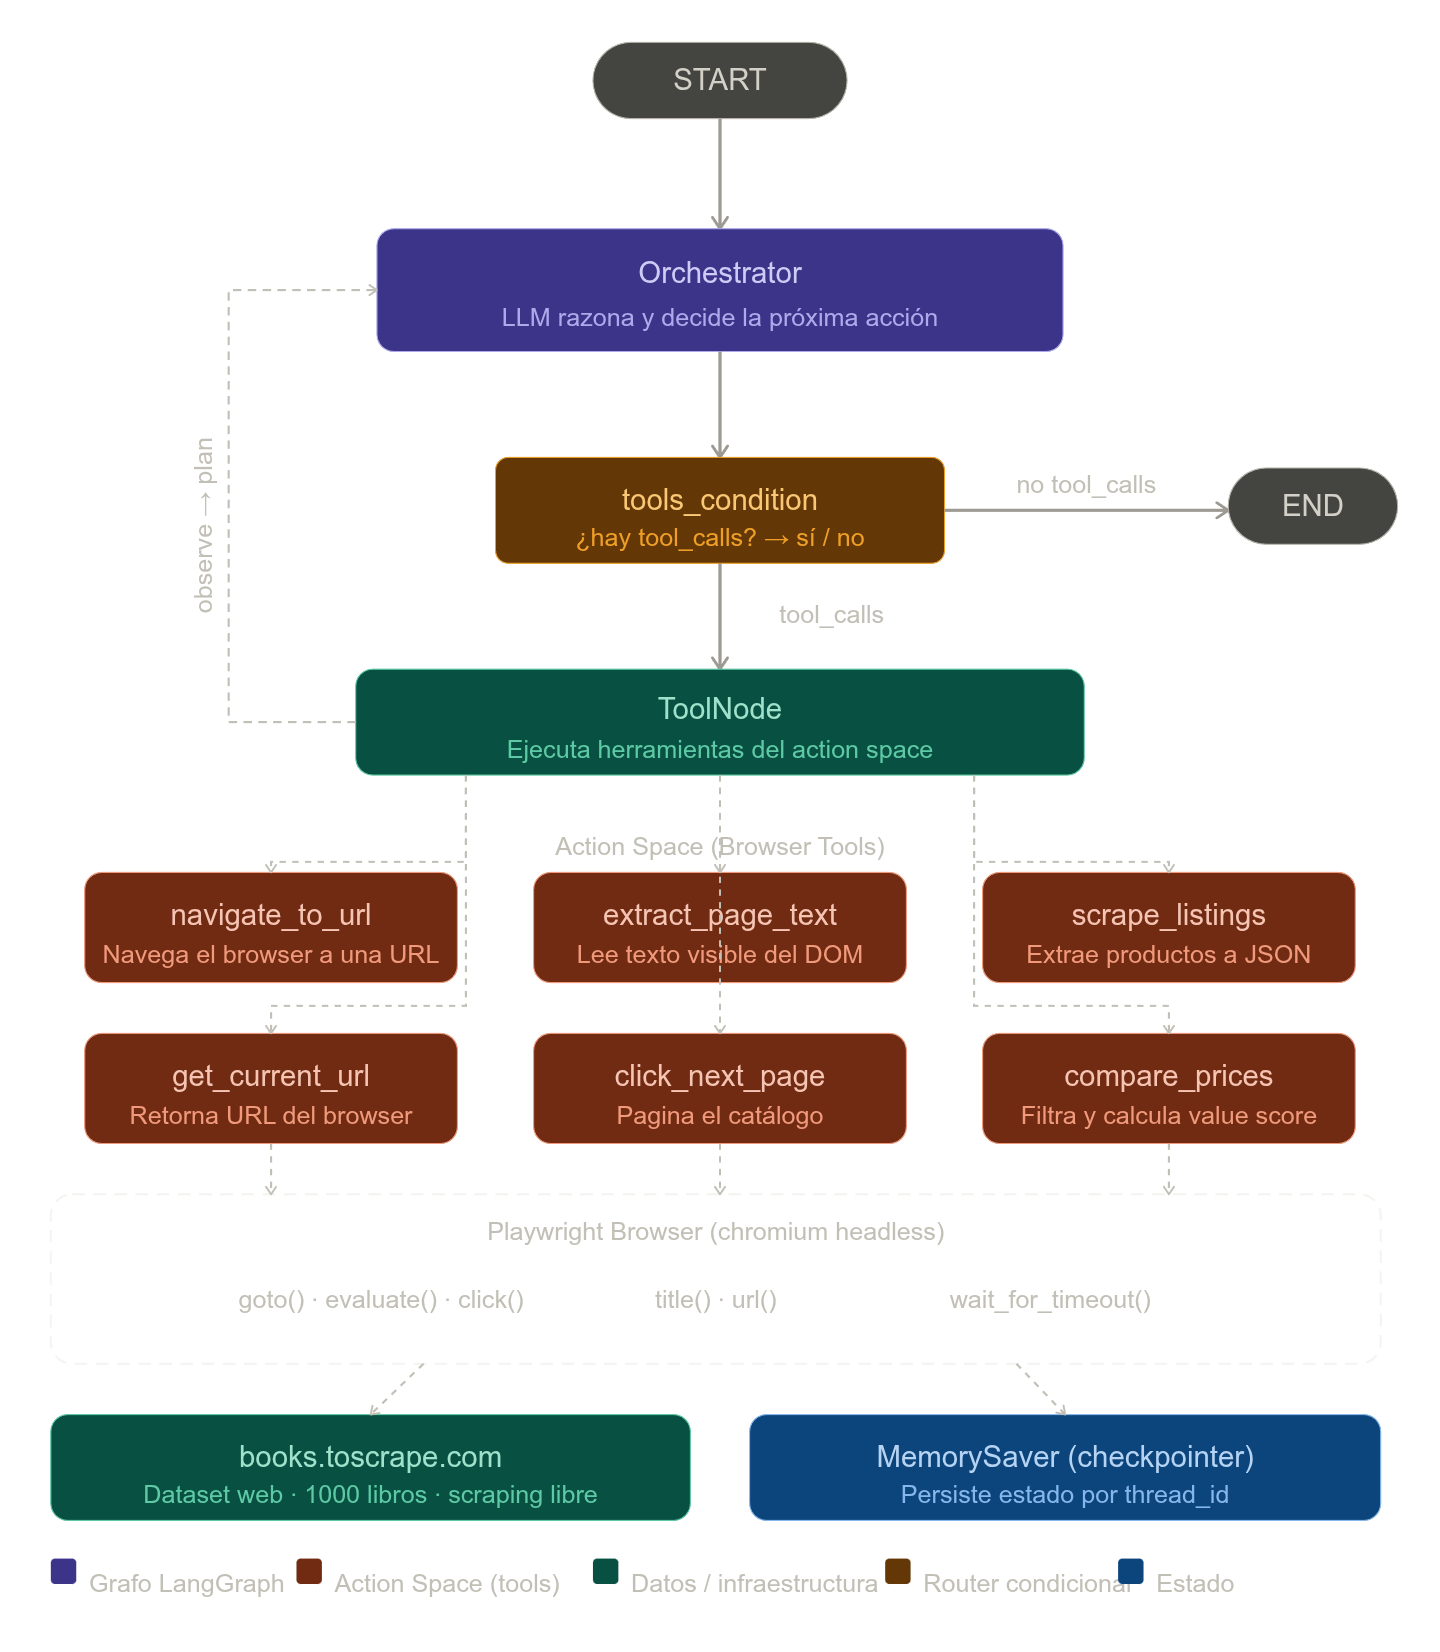

Nodos:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|START|Grafo LangGraph|Punto de entrada|Nodo virtual que inicia la ejecución del grafo. Recibe el CUAState inicial con el mensaje de tarea del usuario y lo pasa al Orchestrator.|
|END|Grafo LangGraph|Punto de salida|Nodo virtual que termina el ciclo del agente. Se activa cuando el Orchestrator produce una respuesta final sin tool_calls, indicando que la tarea fue completada.|
|Orchestrator|Nodo LLM|Razonar y planificar la siguiente acción|Invoca claude-haiku-4-5 con el historial completo de mensajes y el system prompt del CUA. Analiza el estado actual de la navegación (resultados de tools previas) y decide qué herramienta ejecutar a continuación, emitiendo tool_calls. Es el cerebro del loop observe → plan → act.|
|tools_condition|Router condicional|Rutear hacia tools o END|Edge condicional que inspecciona el último mensaje del Orchestrator. Si contiene tool_calls, enruta al ToolNode para ejecución. Si no hay tool_calls (respuesta final en texto), enruta a END. Implementa el criterio de parada del agente.|
|ToolNode|Nodo Executor|Ejecutar herramientas del action space|Nodo prebuilt de LangGraph que recibe los tool_calls del Orchestrator, los ejecuta en paralelo si hay múltiples, y retorna los resultados como ToolMessage. Actúa como el "cuerpo" del agente — traduce las decisiones del LLM en acciones sobre el browser.|
|navigate_to_url|Tool (action)|Navegar a una URL|Wrapper sobre page.goto() de Playwright. Carga la URL objetivo con wait_until="domcontentloaded" y retorna el título de la página. Es la primera acción del CUA en cada sesión de scraping.|
|extract_page_text|Tool (percepción)|Leer texto visible del DOM|Equivalente a "screenshot + OCR" en modo headless. Usa page.evaluate() para extraer el innerText del DOM, removiendo scripts y estilos, y trunca a 4000 caracteres. Permite al agente leer el estado de la página sin visión real.|
|scrape_product_listings|Tool (extracción)|Extraer productos estructurados|Ejecuta un script JS en el browser que selecciona todos los article.product_pod, extrae título, precio, rating (mapeado de clase CSS a número 1-5), disponibilidad y URL de imagen, y retorna un array JSON. Es la herramienta core del caso de uso de monitoreo de precios.|
|get_current_url|Tool (observación)|Retornar la URL actual|Lee page.url del contexto activo de Playwright. Permite al agente saber en qué página se encuentra durante la paginación, útil para verificar el avance y evitar loops infinitos.|
|click_next_page|Tool (acción UI)|Paginar el catálogo|Intenta hacer click en el botón "Next" probando múltiples selectores CSS en orden de prioridad (li.next a, a[rel='next'], etc.). Si ningún selector existe, retorna un mensaje indicando que se llegó al final del catálogo, terminando el loop de paginación.|
|compare_prices_with_threshold|Tool (análisis)|Filtrar y rankear oportunidades|Recibe un JSON de productos, aplica filtros de precio máximo y rating mínimo, calcula el value score (rating / precio × 10), ordena descendentemente y retorna el top 5. Es la capa de análisis del agente — transforma datos crudos en recomendaciones.|
|Playwright Browser|Infraestructura|Entorno de ejecución del browser|Instancia de Chromium headless compartida entre todas las tools mediante _browser_context global. Provee el contexto de navegación persistente durante toda la sesión del CUA. En producción sería reemplazado por un sandbox aislado (E2B, Docker, Scrapybara).|
|books.toscrape.com|Fuente de datos|Dataset web de práctica|Sitio de scraping legal y libre con 1000 libros distribuidos en 50 páginas. Provee: título, precio (GBP), rating (1-5 estrellas), disponibilidad y categoría. No requiere autenticación ni API key. Simula un portal e-commerce real sin API pública.|
|MemorySaver|Estado/Checkpointing|Persistir estado por sesión|Checkpointer de LangGraph que persiste el CUAState completo (historial de mensajes, productos extraídos, páginas visitadas) identificado por thread_id. Permite reanudar sesiones interrumpidas. En producción se reemplaza por PostgresSaver.|
|CUAState|Estado compartido|Transportar contexto entre nodos|TypedDict que fluye entre todos los nodos del grafo. Contiene: messages (historial con reducer append), extracted_data (productos), pages_visited, task_complete, error_count y browser_initialized. Es la "memoria de corto plazo" del CUA.|



### Cuándo usarlo
- ✅ Automatizar sitios web **sin API pública** (portales legacy, scraping ético)
- ✅ Testing de aplicaciones con comportamiento visual cambiante
- ✅ Reemplazar RPA cuando las pantallas cambian entre ejecuciones
- ✅ Extracción de datos de portales con autenticación compleja
- ❌ Cuando existe API disponible → usarla directamente (más eficiente)
- ❌ Tareas de alta frecuencia → latencia del VLM es limitante
- ❌ Sin HITL en acciones irreversibles (comprar, eliminar, enviar emails)

In [1]:
!pip install -q langchain-anthropic langgraph langchain-core

In [2]:
!pip install -q nest-asyncio pandas tabulate

In [3]:
!pip install -q playwright

In [4]:
!playwright install chromium --with-deps

BEWARE: your OS is not officially supported by Playwright; installing dependencies for ubuntu24.04-x64 as a fallback.
Installing dependencies...
Switching to root user to install dependencies...
[sudo: authenticate] Password: 

### Imports y configuración

In [5]:
import os
import json
import asyncio
import re
from typing import TypedDict, Annotated, Optional
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()  # Necesario para usar asyncio en Jupyter

from langchain_anthropic import ChatAnthropic
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

import pandas as pd

from dotenv import load_dotenv
load_dotenv()

True

In [6]:
llm = ChatAnthropic(model="claude-haiku-4-5", max_tokens=2048)

print("✅ Dependencias cargadas")
print(f"📅 Sesión iniciada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Dependencias cargadas
📅 Sesión iniciada: 2026-04-05 17:56:51


### Definición del Estado del CUA

In [7]:
# ==============================================================
# STATE del CUA
# El estado lleva el historial de mensajes + datos extraídos
# + metadata de la sesión de browser
# ==============================================================

class CUAState(TypedDict):
    """
    Estado compartido del Computer Use Agent.

    - messages: historial completo de conversación (MessagesState pattern)
    - extracted_data: productos/precios extraídos de la web
    - pages_visited: URLs visitadas en la sesión
    - task_complete: flag para terminar el loop observe→plan→act
    - error_count: contador de errores para circuit breaker
    - browser_initialized: flag de estado del browser
    """
    messages: Annotated[list, lambda x, y: x + y]  # reducer: append messages
    extracted_data: list[dict]
    pages_visited: list[str]
    task_complete: bool
    error_count: int
    browser_initialized: bool

### Herramientas del Browser (Action Space del CUA)

In [8]:
# ==============================================================
# ACTION SPACE DEL CUA
# Playwright como "manos" del agente sobre el browser
# Implementa el action space definido en la nota de Obsidian:
#   - navigate(url)
#   - get_dom()
#   - screenshot() → en modo headless, se lee el texto del DOM
#   - find_element()
#   - extract_text()
# ==============================================================

# Browser compartido entre herramientas (estado global de la sesión)
_browser_context = {"browser": None, "page": None}

async def _get_page():
    """Obtiene o inicializa la página del browser."""
    from playwright.async_api import async_playwright
    if _browser_context["browser"] is None:
        pw = await async_playwright().start()
        _browser_context["pw"] = pw
        _browser_context["browser"] = await pw.chromium.launch(headless=True)
        _browser_context["page"] = await _browser_context["browser"].new_page()
        # User-agent realista para evitar bloqueos
        await _browser_context["page"].set_extra_http_headers({
            "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36"
        })
    return _browser_context["page"]

async def _close_browser():
    """Cierra el browser al finalizar."""
    if _browser_context["browser"]:
        await _browser_context["browser"].close()
        await _browser_context["pw"].stop()
        _browser_context["browser"] = None
        _browser_context["page"] = None


@tool
async def navigate_to_url(url: str) -> str:
    """
    Navega el browser a una URL específica.
    Retorna el título de la página y un resumen del contenido visible.
    Úsalo para ir a sitios web, portales o páginas de productos.
    """
    try:
        page = await _get_page()
        await page.goto(url, wait_until="domcontentloaded", timeout=30000)
        await page.wait_for_timeout(1000)  # espera carga dinámica
        title = await page.title()
        return f"✅ Navegado a: {url}\nTítulo: {title}"
    except Exception as e:
        return f"❌ Error al navegar a {url}: {str(e)}"


@tool
async def extract_page_text() -> str:
    """
    Extrae el texto visible completo de la página actual.
    Útil para leer contenido, precios, descripciones y ratings.
    Equivalente a 'screenshot + OCR' en modo headless.
    """
    try:
        page = await _get_page()
        # Extraer solo el texto relevante, no el HTML completo
        text = await page.evaluate("""() => {
            // Remover scripts, styles y elementos ocultos
            const clone = document.body.cloneNode(true);
            clone.querySelectorAll('script, style, nav, footer').forEach(el => el.remove());
            return clone.innerText.substring(0, 4000);
        }""")
        return f"📄 Contenido de la página:\n{text}"
    except Exception as e:
        return f"❌ Error al extraer texto: {str(e)}"


@tool
async def scrape_product_listings() -> str:
    """
    Extrae TODOS los productos de la página actual en formato estructurado.
    Retorna JSON con: título, precio, rating, disponibilidad y URL de cada producto.
    Úsalo en páginas de catálogo o listados de productos.
    """
    try:
        page = await _get_page()

        products = await page.evaluate("""() => {
            const items = [];
            // Selector para books.toscrape.com (catálogo estándar de e-commerce)
            const articles = document.querySelectorAll('article.product_pod');

            articles.forEach(article => {
                const titleEl = article.querySelector('h3 a');
                const priceEl = article.querySelector('.price_color');
                const ratingEl = article.querySelector('.star-rating');
                const availEl = article.querySelector('.availability');
                const imgEl = article.querySelector('img');

                // Mapeo de clases CSS a números de rating
                const ratingMap = {
                    'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5
                };

                const ratingClass = ratingEl ?
                    Array.from(ratingEl.classList).find(c => c !== 'star-rating') : '';

                items.push({
                    title: titleEl ? titleEl.getAttribute('title') : 'N/A',
                    price: priceEl ? priceEl.innerText.trim() : 'N/A',
                    rating: ratingMap[ratingClass] || 0,
                    availability: availEl ? availEl.innerText.trim() : 'N/A',
                    url: titleEl ? titleEl.getAttribute('href') : '',
                    image: imgEl ? imgEl.getAttribute('src') : ''
                });
            });
            return items;
        }""")

        if not products:
            return "⚠️ No se encontraron productos en esta página. Puede que el selector no coincida."

        return f"📦 {len(products)} productos encontrados:\n{json.dumps(products, indent=2, ensure_ascii=False)}"

    except Exception as e:
        return f"❌ Error al extraer productos: {str(e)}"


@tool
async def get_current_url() -> str:
    """
    Retorna la URL actual del browser y el número de página si aplica.
    Útil para saber dónde está el agente en su recorrido por el sitio.
    """
    try:
        page = await _get_page()
        url = page.url
        return f"🌐 URL actual: {url}"
    except Exception as e:
        return f"❌ Error: {str(e)}"


@tool
async def click_next_page() -> str:
    """
    Hace click en el botón 'Next' / 'Siguiente' para ir a la próxima página del catálogo.
    Retorna la nueva URL después del click.
    Úsalo para paginar a través de múltiples páginas de productos.
    """
    try:
        page = await _get_page()
        # Intentar múltiples selectores para el botón 'next'
        selectors = [
            "li.next a",           # books.toscrape.com
            "a[rel='next']",       # estándar HTML
            "a:text('Next')",      # texto visible
            ".pagination .next a", # Bootstrap pagination
        ]

        clicked = False
        for selector in selectors:
            try:
                await page.click(selector, timeout=3000)
                clicked = True
                break
            except Exception:
                continue

        if clicked:
            await page.wait_for_timeout(1500)
            new_url = page.url
            return f"✅ Página siguiente cargada: {new_url}"
        else:
            return "🏁 No hay más páginas. Se alcanzó el final del catálogo."
    except Exception as e:
        return f"❌ Error al paginar: {str(e)}"


@tool
async def filter_by_category(category_name: str) -> str:
    """
    Navega a la categoría específica del catálogo (por ejemplo: 'mystery', 'science', 'travel').
    Construye la URL de la categoría en books.toscrape.com.
    """
    try:
        page = await _get_page()
        # En books.toscrape.com las categorías son parte del sidebar
        links = await page.evaluate(f"""() => {{
            const allLinks = Array.from(document.querySelectorAll('ul.nav-list a'));
            return allLinks
                .filter(a => a.innerText.trim().toLowerCase().includes('{category_name.lower()}'))
                .map(a => ({{ text: a.innerText.trim(), href: a.href }}));
        }}""")

        if links:
            category_url = links[0]["href"]
            await page.goto(category_url, wait_until="domcontentloaded", timeout=30000)
            await page.wait_for_timeout(1000)
            title = await page.title()
            return f"✅ Categoría '{links[0]['text']}' cargada\nURL: {category_url}\nTítulo: {title}"
        else:
            return f"⚠️ Categoría '{category_name}' no encontrada. Categorías disponibles en el sidebar."
    except Exception as e:
        return f"❌ Error: {str(e)}"


@tool
async def compare_prices_with_threshold(
    products_json: str,
    max_price: float,
    min_rating: int
) -> str:
    """
    Analiza una lista de productos (JSON string) y filtra aquellos que:
    - Tienen precio <= max_price (en GBP, ej: 20.0)
    - Tienen rating >= min_rating (1-5 estrellas)
    Retorna un resumen de las mejores oportunidades encontradas.
    """
    try:
        products = json.loads(products_json)

        opportunities = []
        for p in products:
            # Extraer precio numérico (remover símbolo £)
            price_str = p.get("price", "£999").replace("£", "").replace("Â", "").strip()
            try:
                price = float(price_str)
            except ValueError:
                continue

            rating = p.get("rating", 0)

            if price <= max_price and rating >= min_rating:
                opportunities.append({
                    **p,
                    "price_numeric": price,
                    "value_score": round(rating / price * 10, 2)  # rating/precio ratio
                })

        # Ordenar por value_score (mejor relación calidad/precio)
        opportunities.sort(key=lambda x: x["value_score"], reverse=True)

        if not opportunities:
            return f"📊 Ningún producto cumple los criterios (precio ≤ £{max_price}, rating ≥ {min_rating}⭐)"

        summary = f"🏆 {len(opportunities)} productos con buena relación calidad/precio:\n"
        for i, p in enumerate(opportunities[:5], 1):
            summary += (
                f"\n{i}. {p['title'][:50]}...\n"
                f"   💰 Precio: {p['price']} | ⭐ Rating: {p['rating']}/5 "
                f"| 📈 Value Score: {p['value_score']}\n"
            )

        return summary
    except Exception as e:
        return f"❌ Error en análisis de precios: {str(e)}"


print("✅ Action Space del CUA definido:")
print("   - navigate_to_url")
print("   - extract_page_text")
print("   - scrape_product_listings")
print("   - get_current_url")
print("   - click_next_page")
print("   - filter_by_category")
print("   - compare_prices_with_threshold")

✅ Action Space del CUA definido:
   - navigate_to_url
   - extract_page_text
   - scrape_product_listings
   - get_current_url
   - click_next_page
   - filter_by_category
   - compare_prices_with_threshold


### Construcción del Grafo LangGraph CUA

In [9]:
# ==============================================================
# GRAFO CUA con LangGraph
# Flujo: START → orchestrator → [vlm_perceive] → plan_action
#              → [hitl si riesgoso] → execute → observe → loop
#
# Para este caso de uso (web scraping ético) no hay acciones
# destructivas, por lo que el HITL se omite.
# El loop es: orchestrator ↔ tools hasta task_complete
# ==============================================================

# Lista de todas las tools del CUA
cua_tools = [
    navigate_to_url,
    extract_page_text,
    scrape_product_listings,
    get_current_url,
    click_next_page,
    filter_by_category,
    compare_prices_with_threshold,
]

# LLM con tools vinculadas
llm_with_tools = llm.bind_tools(cua_tools)

# System prompt del CUA (siguiendo las 7 componentes de la nota)
CUA_SYSTEM_PROMPT = """Eres un Computer Use Agent (CUA) especializado en monitoreo de precios en e-commerce.

## Purpose
Navegar sitios web de e-commerce para extraer precios, ratings y disponibilidad de productos de forma autónoma.

## Instructions
1. SIEMPRE empieza navegando a la URL objetivo con `navigate_to_url`
2. Usa `scrape_product_listings` para extraer productos estructurados de cada página
3. Usa `click_next_page` para paginar y recopilar más productos
4. Usa `compare_prices_with_threshold` para analizar y filtrar las mejores oportunidades
5. El loop observe → plan → act se repite hasta completar la tarea o agotar las páginas
6. Cuando hayas recopilado suficiente información, presenta un resumen claro en español

## Output Description
- Lista de productos con precio, rating y value score
- Top 5 mejores oportunidades calidad/precio
- Estadísticas generales: promedio de precio, distribución de ratings

## Constraints
- Solo visitas páginas del dominio autorizado en la tarea
- No realizas acciones destructivas (compras, registros, etc.)
- Máximo 5 páginas por sesión para evitar sobrecargar el servidor
- Respeta los tiempos de espera entre requests

Actúa de forma autónoma. Usa las herramientas necesarias sin pedir confirmación para acciones de lectura.
"""


def orchestrator_node(state: CUAState) -> dict:
    """
    Nodo principal del CUA: el VLM/LLM decide la siguiente acción.
    En cada iteración del loop observe→plan→act:
    - Observa el estado actual (messages con resultados previos)
    - Planifica la siguiente acción
    - Emite tool_calls con la acción a ejecutar
    """
    messages = [
        SystemMessage(content=CUA_SYSTEM_PROMPT),
        *state["messages"]
    ]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def should_continue(state: CUAState) -> str:
    """
    Router del CUA: decide si continuar el loop o terminar.

    - Si el último mensaje tiene tool_calls → ejecutar herramienta → continuar
    - Si no hay tool_calls → el agente llegó a una conclusión → END
    """
    last_message = state["messages"][-1]

    # Si hay tool calls, continuar el loop observe→act
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

    # Sin tool calls = respuesta final del agente
    return END


# ── Construir el Grafo ───────────────────────────────────────────
builder = StateGraph(CUAState)

# Nodos
builder.add_node("orchestrator", orchestrator_node)
builder.add_node("tools", ToolNode(cua_tools))  # Ejecuta las tools en paralelo si hay múltiples calls

# Flujo
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges(
    "orchestrator",
    should_continue,
    {"tools": "tools", END: END}
)
builder.add_edge("tools", "orchestrator")  # Loop: después de ejecutar tool → volver al orchestrator

# Compilar con checkpointing para poder resumir sesiones
checkpointer = MemorySaver()
cua_graph = builder.compile(checkpointer=checkpointer)

print("✅ Grafo CUA compilado")
print("\n📊 Estructura del grafo:")
print("  START → orchestrator → (tools) → orchestrator → ... → END")
print("  Loop: orchestrator ↔ tools hasta respuesta final sin tool_calls")

✅ Grafo CUA compilado

📊 Estructura del grafo:
  START → orchestrator → (tools) → orchestrator → ... → END
  Loop: orchestrator ↔ tools hasta respuesta final sin tool_calls


### Visualización del Grafo

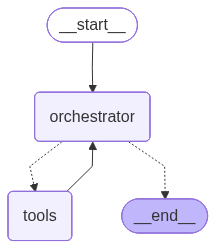

✅ Grafo visualizado


In [10]:
try:
    from IPython.display import Image, display
    img = cua_graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo visualizado")
except Exception as e:
    print(f"Visualización no disponible: {e}")
    print("Mermaid del grafo:")
    print(cua_graph.get_graph().draw_mermaid())

### Ejecución del CUA (Tarea de Monitoreo de Precios)

In [14]:
# ==============================================================
# CELDA 7 — CORREGIDA
# Cambios:
#   1. Estado compartido externo al async for (no depende del stream)
#   2. Sin truncar content al parsear JSON
#   3. all_products declarado en scope global del notebook
# ==============================================================

import json, asyncio
from langchain_core.messages import HumanMessage

# Variable global del notebook para compartir con celda 8
all_products_global = []

async def run_cua_price_monitor_v2(task: str, thread_id: str = "cua-session-001"):
    global all_products_global
    all_products_global = []  # reset

    config = {"configurable": {"thread_id": thread_id}}

    initial_state = {
        "messages": [HumanMessage(content=task)],
        "extracted_data": [],
        "pages_visited": [],
        "task_complete": False,
        "error_count": 0,
        "browser_initialized": False,
    }

    print("🤖 CUA iniciado")
    print(f"📋 Tarea: {task}")
    print("=" * 60)

    step = 0

    async for event in cua_graph.astream(initial_state, config, stream_mode="updates"):
        for node_name, node_output in event.items():
            step += 1
            messages = node_output.get("messages", [])

            if node_name == "orchestrator":
                last_msg = messages[-1] if messages else None
                if last_msg:
                    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
                        print(f"\n🧠 [{step}] Orchestrator → Plan:")
                        for tc in last_msg.tool_calls:
                            args_preview = str(tc.get("args", {}))[:120]
                            print(f"   ▶ {tc['name']}({args_preview})")
                    else:
                        print(f"\n✅ [{step}] Orchestrator → Respuesta Final:")
                        print(f"   {last_msg.content[:800]}")

            elif node_name == "tools":
                print(f"\n🔧 [{step}] Tools ejecutadas:")
                for msg in messages:
                    # Obtener contenido completo SIN truncar
                    raw_content = msg.content if isinstance(msg.content, str) else str(msg.content)
                    print(f"   → {raw_content[:400]}")  # solo para display

                    # Capturar productos: buscar el bloque JSON completo
                    if "productos encontrados" in raw_content.lower():
                        try:
                            json_start = raw_content.find("[")
                            json_end   = raw_content.rfind("]")
                            if json_start >= 0 and json_end > json_start:
                                # Usar raw_content completo, no truncado
                                products_json = raw_content[json_start:json_end + 1]
                                parsed = json.loads(products_json)
                                all_products_global.extend(parsed)
                                print(f"   ✅ Capturados {len(parsed)} productos (total: {len(all_products_global)})")
                        except json.JSONDecodeError as e:
                            print(f"   ⚠️  JSON parse error: {e}")

    print("\n" + "=" * 60)
    print(f"🏁 Sesión completada | Steps: {step} | Total productos: {len(all_products_global)}")
    return all_products_global


TAREA = """
Ve al sitio web http://books.toscrape.com y realiza las siguientes acciones:

1. Navega a la categoría 'Mystery'
2. Extrae TODOS los productos de la primera página con scrape_product_listings
3. Pasa a la siguiente página y extrae más productos
4. Analiza los productos encontrados y filtra los que tienen:
   - Precio menor o igual a £20
   - Rating de 4 o 5 estrellas
5. Presenta el top 5 de mejores libros ordenados por value score

Actúa de forma autónoma. Usa las herramientas disponibles.
"""

products = asyncio.run(run_cua_price_monitor_v2(TAREA))

🤖 CUA iniciado
📋 Tarea: 
Ve al sitio web http://books.toscrape.com y realiza las siguientes acciones:

1. Navega a la categoría 'Mystery'
2. Extrae TODOS los productos de la primera página con scrape_product_listings
3. Pasa a la siguiente página y extrae más productos
4. Analiza los productos encontrados y filtra los que tienen:
   - Precio menor o igual a £20
   - Rating de 4 o 5 estrellas
5. Presenta el top 5 de mejores libros ordenados por value score

Actúa de forma autónoma. Usa las herramientas disponibles.


🧠 [1] Orchestrator → Plan:
   ▶ navigate_to_url({'url': 'http://books.toscrape.com'})

🔧 [2] Tools ejecutadas:
   → ✅ Navegado a: http://books.toscrape.com
Título: All products | Books to Scrape - Sandbox

🧠 [3] Orchestrator → Plan:
   ▶ filter_by_category({'category_name': 'mystery'})

🔧 [4] Tools ejecutadas:
   → ✅ Categoría 'Mystery' cargada
URL: http://books.toscrape.com/catalogue/category/books/mystery_3/index.html
Título: Mystery | Books to Scrape - Sandbox

🧠 [5] Orc

### Análisis de Resultados con Pandas


In [15]:
# ==============================================================
# CELDA 8 — CORREGIDA
# Usa all_products_global como fallback si products está vacío
# ==============================================================
import pandas as pd

# Usar la variable global como respaldo
data = products if products else all_products_global

if not data:
    print("⚠️ No se capturaron productos.")
    print("💡 Verifica en los logs de la celda 7 que el agente llamó a scrape_product_listings")
    print("   y que la respuesta contenía '📦 N productos encontrados:'")
else:
    df = pd.DataFrame(data)
    print(f"✅ DataFrame creado con {len(df)} productos")

    # Limpiar precio
    df["price_numeric"] = (
        df["price"]
        .str.replace(r"[^\d.]", "", regex=True)
        .astype(float)
    )

    print("\n📊 ANÁLISIS DE PRODUCTOS EXTRAÍDOS POR EL CUA")
    print("=" * 60)
    print(f"📦 Total productos: {len(df)}")
    print(f"💰 Precio promedio: £{df['price_numeric'].mean():.2f}")
    print(f"💰 Precio mínimo:   £{df['price_numeric'].min():.2f}")
    print(f"💰 Precio máximo:   £{df['price_numeric'].max():.2f}")

    print(f"\n⭐ Distribución de ratings:")
    for rating, count in df["rating"].value_counts().sort_index().items():
        print(f"   {rating}⭐: {'█' * count} ({count})")

    df["value_score"] = (df["rating"] / df["price_numeric"] * 10).round(2)
    top5 = df[df["price_numeric"] <= 20].nlargest(5, "value_score")

    print(f"\n🏆 TOP 5 MEJORES OPORTUNIDADES (precio ≤ £20):")
    print("-" * 60)
    for i, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"{i}. {row['title'][:50]}")
        print(f"   💰 £{row['price_numeric']:.2f} | ⭐ {row['rating']}/5 | 📈 Score: {row['value_score']}")

    display_cols = ["title", "price", "rating", "availability", "value_score"]
    print(f"\n📋 DataFrame completo:")
    print(df[display_cols].sort_values("value_score", ascending=False).to_string(index=False))

✅ DataFrame creado con 32 productos

📊 ANÁLISIS DE PRODUCTOS EXTRAÍDOS POR EL CUA
📦 Total productos: 32
💰 Precio promedio: £31.72
💰 Precio mínimo:   £10.69
💰 Precio máximo:   £59.48

⭐ Distribución de ratings:
   1⭐: ███████ (7)
   2⭐: █████ (5)
   3⭐: ████████ (8)
   4⭐: ███████ (7)
   5⭐: █████ (5)

🏆 TOP 5 MEJORES OPORTUNIDADES (precio ≤ £20):
------------------------------------------------------------
1. The Girl You Lost
   💰 £12.29 | ⭐ 5/5 | 📈 Score: 4.07
2. Playing with Fire
   💰 £13.71 | ⭐ 3/5 | 📈 Score: 2.19
3. The Girl In The Ice (DCI Erika Foster #1)
   💰 £15.85 | ⭐ 3/5 | 📈 Score: 1.89
4. A Study in Scarlet (Sherlock Holmes #1)
   💰 £16.73 | ⭐ 2/5 | 📈 Score: 1.2
5. Tastes Like Fear (DI Marnie Rome #3)
   💰 £10.69 | ⭐ 1/5 | 📈 Score: 0.94

📋 DataFrame completo:
                                                                   title  price  rating availability  value_score
                                                       The Girl You Lost £12.29       5     In stock    

###  Cerrar el Browser y Limpiar

In [16]:
# ==============================================================
# CLEANUP: Cerrar el browser de Playwright
# Siempre ejecutar al finalizar la sesión del CUA
# ==============================================================

async def cleanup():
    await _close_browser()
    print("🧹 Browser cerrado correctamente")

asyncio.run(cleanup())

🧹 Browser cerrado correctamente


### Resumen del Patrón y Cuándo Usarlo

In [17]:
# ==============================================================
# RESUMEN DEL PATRÓN 11: CUA
# ==============================================================

resumen = {
    "patron": "CUA — Computer Use Agent",
    "caso_de_uso": "Price Monitoring Agent en e-commerce",
    "dataset_fuente": {
        "nombre": "books.toscrape.com",
        "tipo": "Sitio web de práctica (scraping legal)",
        "url": "http://books.toscrape.com",
        "datos": "1000 libros con precio, rating, categoría, disponibilidad",
        "alternativa_kaggle": "kaggle.com/datasets/jealousleopard/goodreadsbooks"
    },
    "stack": {
        "llm": "claude-haiku-4-5 (orquestador) / claude-opus-4-6 (CUA nativo)",
        "browser": "Playwright (chromium headless)",
        "framework": "LangGraph StateGraph",
        "checkpointing": "MemorySaver (dev) / PostgresSaver (prod)",
    },
    "action_space": [
        "navigate_to_url",
        "extract_page_text",
        "scrape_product_listings",
        "get_current_url",
        "click_next_page",
        "filter_by_category",
        "compare_prices_with_threshold",
    ],
    "cuando_usarlo": [
        "✅ Monitorear precios en sitios sin API pública",
        "✅ Scraping ético de portales con JS dinámico",
        "✅ Testing automatizado de UIs que cambian frecuentemente",
        "✅ Portales legacy sin API (sistemas bancarios, gubernamentales)",
        "✅ RPA inteligente donde las pantallas cambian entre ejecuciones",
    ],
    "cuando_NO_usarlo": [
        "❌ Cuando existe API disponible → usarla directamente",
        "❌ Tareas de alta frecuencia → latencia del LLM es limitante",
        "❌ Sin sandbox aislado en acciones irreversibles",
        "❌ Sitios con anti-bot agresivo sin solución ética",
    ],
    "produccion": {
        "sandbox": "E2B / Daytona / Scrapybara / Docker+Xvfb",
        "hitl": "interrupt() en acciones de compra/registro",
        "seguridad": "Lista blanca de dominios + rate limiting",
        "observabilidad": "LangSmith para trazabilidad de steps",
    }
}

print("=" * 60)
print("📋 RESUMEN: PATRÓN 11 — CUA")
print("=" * 60)

for key, value in resumen.items():
    if isinstance(value, dict):
        print(f"\n🔹 {key.upper()}:")
        for k, v in value.items():
            print(f"   {k}: {v}")
    elif isinstance(value, list):
        print(f"\n🔹 {key.upper()}:")
        for item in value:
            print(f"   {item}")
    else:
        print(f"\n🔹 {key.upper()}: {value}")

print("\n" + "=" * 60)
print("💡 Próximo patrón: Combinar CUA + HITL para acciones de alto riesgo")
print("   Ver: Patrón 8 (HITL) + Patrón 11 (CUA) en la nota de Obsidian")

📋 RESUMEN: PATRÓN 11 — CUA

🔹 PATRON: CUA — Computer Use Agent

🔹 CASO_DE_USO: Price Monitoring Agent en e-commerce

🔹 DATASET_FUENTE:
   nombre: books.toscrape.com
   tipo: Sitio web de práctica (scraping legal)
   url: http://books.toscrape.com
   datos: 1000 libros con precio, rating, categoría, disponibilidad
   alternativa_kaggle: kaggle.com/datasets/jealousleopard/goodreadsbooks

🔹 STACK:
   llm: claude-haiku-4-5 (orquestador) / claude-opus-4-6 (CUA nativo)
   browser: Playwright (chromium headless)
   framework: LangGraph StateGraph
   checkpointing: MemorySaver (dev) / PostgresSaver (prod)

🔹 ACTION_SPACE:
   navigate_to_url
   extract_page_text
   scrape_product_listings
   get_current_url
   click_next_page
   filter_by_category
   compare_prices_with_threshold

🔹 CUANDO_USARLO:
   ✅ Monitorear precios en sitios sin API pública
   ✅ Scraping ético de portales con JS dinámico
   ✅ Testing automatizado de UIs que cambian frecuentemente
   ✅ Portales legacy sin API (sistemas ban